Guardado: grafico_diametro_edad.png
Guardado: grafico_crateres_por_pais.png
Guardado: grafico_ubicaciones_geograficas.png


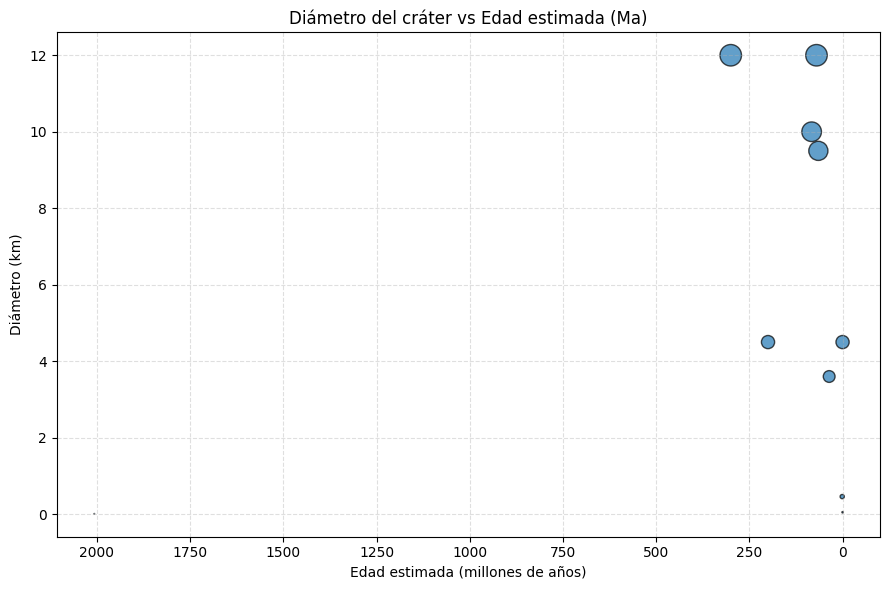

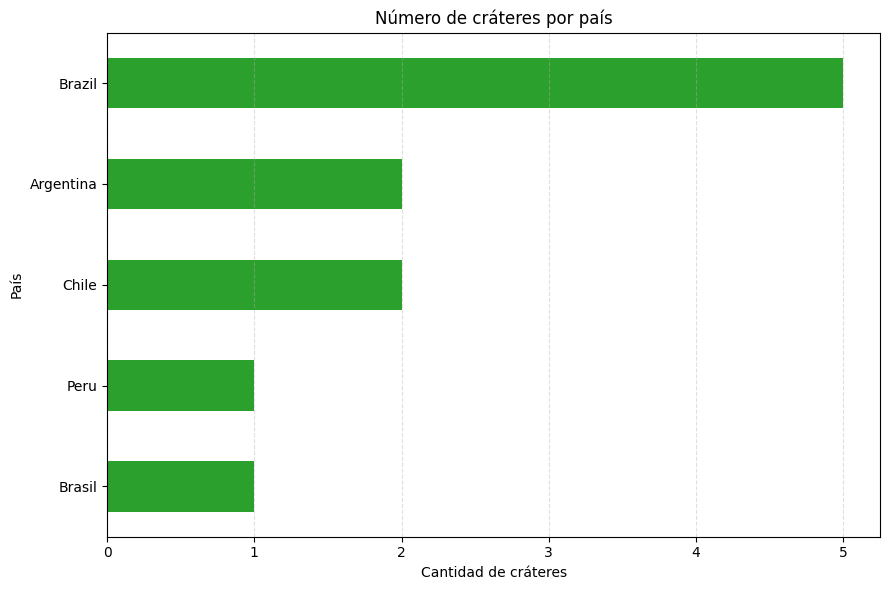

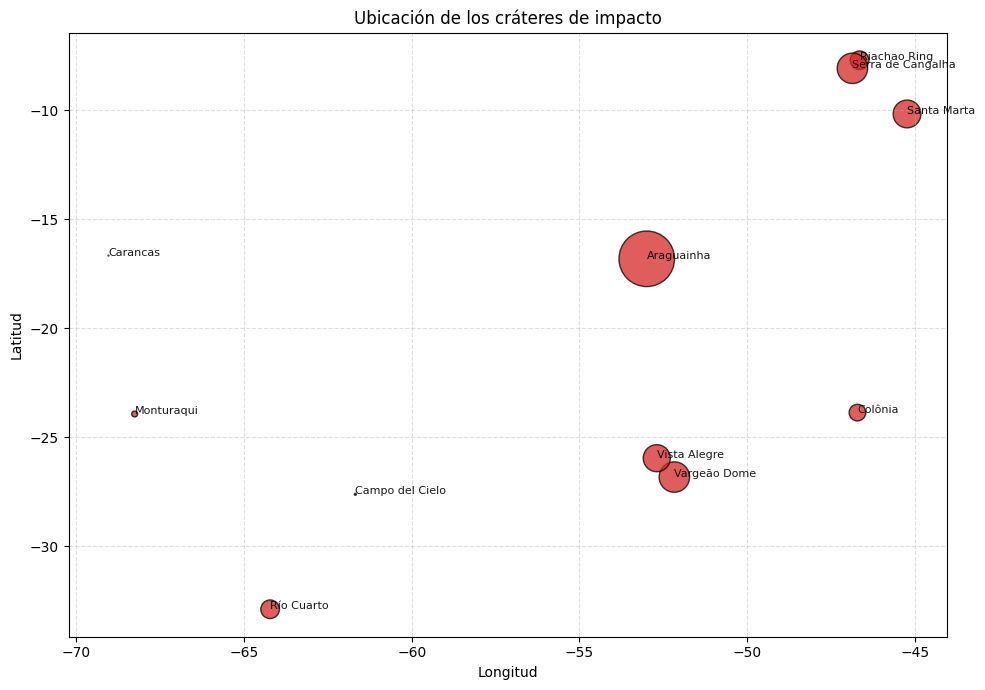

In [ ]:
# Parte 1: Importar librerías
import io
import os
import re
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Parte 2: Definir los datos en formato CSV
csv_data = '''FID,OBJECTID_1,Name,Location,Latitude,Longitude,Diameter_k,Age_Ma,Exposed,Drilled,TargetRock,BolideType,URL,x,y
1,5,Vargeão Dome,Brazil,"26° 49' 06,000"""" S","52° 10' 08,000"""" W",12,<70,Yes,No,Cretaceous basalts and Jurassic-Triassic sandstones, ,http://www.passc.net/EarthImpactDatabase/vargeardome.html,-52.169,-26.818
2,8,Colônia,Brazil,"23° 51' 52,000"""" S","46° 42' 31,000"""" W",3.6,may.-36,Yes,Yes,Crystalline rocks of Precambrian basement, ,http://www.passc.net/EarthImpactDatabase/colonia.html,-46.709,-23.864
3,3,Araguainha,Brasil,"16° 48' 51,000"""" S","52° 59' 31,000"""" W",40,"254,7 ±2,5",Yes,No,"Paleozoic siltstones, claystones and red sandstones", ,http://www.passc.net/EarthImpactDatabase/araguainha.html,-52.992,-16.814
4,12,Carancas,Peru,"16° 39' 52,250"""" S","69° 02' 38,800"""" W",0.01,Impact in 2007,Yes,No,River deposit,C,http://www.passc.net/EarthImpactDatabase/carancas.html,-69.044,-16.665
5,1,Campo del Cielo,Argentina,"27° 36' 36,000"""" S","61° 40' 52,000"""" W",0.05,">0,004",Yes,Yes,Sandy clay sediments of Pleistocene-Holocene age,Coarse Octahedrite to Granular Hexahedrite,http://www.passc.net/EarthImpactDatabase/campodelcielo.html,-61.681,-27.61
6,2,Río Cuarto,Argentina,"32° 52' 43,000"""" S","64° 13' 23,000"""" W",4.5,">0,1",Yes,No,Holocene aeolian sediments,Chondrite (H),http://www.passc.net/EarthImpactDatabase/riocuarto.html,-64.223,-32.879
7,11,Santa Marta,Chile,"10° 10' 30,982"""" S","45° 13' 48,490"""" W",10,66-100,Yes,No,Metamorphic, ,http://www.passc.net/EarthImpactDatabase/santamarta.html,-45.23,-10.175
8,6,Riachao Ring,Brazil,"07° 42' 55,000"""" S","46° 38' 41,000"""" W",4.5,<200,Yes,No,Permian sandstones, ,http://www.passc.net/EarthImpactDatabase/riachaoring.html,-46.645,-7.715
9,7,Vista Alegre,Brazil,"25° 57' 15,000"""" S","52° 41' 34,000"""" W",9.5,<65,Yes,No,Cretaceous basalts, ,http://www.passc.net/EarthImpactDatabase/vistaalegre.html,-52.693,-25.954
10,4,Serra de Cangalha,Brazil,"08° 04' 57,000"""" S","46° 51' 31,000"""" W",12,<300,Yes,Yes,Paleozoic sandstones and shales, ,http://www.passc.net/EarthImpactDatabase/serradacangalha.html,-46.859,-8.083
11,9,Monturaqui,Chile,"23° 55' 41,000"""" S","68° 15' 42,000"""" W",0.46,<1,Yes,No,Paleozoic granitic rocks covered by thin bed of Pliocene-Pleistocene ignimbrites,IAB,http://www.passc.net/EarthImpactDatabase/monturaqui.html,-68.262,-23.928
'''

# Parte 3: Función para normalizar la edad de los cráteres
# Esta función limpia y convierte valores como <70, may.-36, 254,7 ±2,5, Impact in 2007, >0,004 o 66-100.
def parse_age(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if text.startswith('<'):
        text = text[1:]
    text = text.replace('may.-', '')
    text = text.replace('Impact in ', '')
    text = text.replace('>', '').replace('±', '+/-')
    text = text.replace(' ', '')
    text = text.replace(',', '.')

    if '-' in text:
        parts = [p for p in text.split('-') if p]
        try:
            nums = [float(p) for p in parts]
            return sum(nums) / len(nums)
        except ValueError:
            return None

    try:
        return float(re.search(r"[0-9]+(?:\.[0-9]+)?", text).group())
    except Exception:
        return None


# Parte 4: Configuración de la base de datos SQLite
DB_PATH = 'impactos.db'
TABLE_NAME = 'impactos'

def create_database(path):
    df_source = pd.read_csv(io.StringIO(csv_data), quotechar='"', skipinitialspace=True)
    with sqlite3.connect(path) as conn:
        df_source.to_sql(TABLE_NAME, conn, if_exists='replace', index=False)


def load_database(path):
    with sqlite3.connect(path) as conn:
        return pd.read_sql_query(f'SELECT * FROM {TABLE_NAME}', conn)


# Parte 5: Crear la base de datos si no existe y cargar los datos
if not os.path.exists(DB_PATH):
    create_database(DB_PATH)

df = load_database(DB_PATH)

# Normalizar algunos valores en el DataFrame
if 'Location' in df.columns:
    df['Country'] = df['Location'].astype(str).str.strip()
else:
    df['Country'] = df['Name'].astype(str)

df['Diameter_k'] = pd.to_numeric(df['Diameter_k'], errors='coerce')
df['Age_numeric'] = df['Age_Ma'].apply(parse_age)
df['Latitude'] = pd.to_numeric(df['y'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['x'], errors='coerce')


# Parte 6: Función para guardar las figuras
def save_fig(fig, name):
    fig.tight_layout()
    fig.savefig(name, dpi=150)
    print(f'Guardado: {name}')


# Parte 7: Gráfico 1 - Diámetro vs Edad estimada
fig1, ax1 = plt.subplots(figsize=(9, 6))
scatter = ax1.scatter(
    df['Age_numeric'],
    df['Diameter_k'],
    s=df['Diameter_k'].fillna(1) * 20,
    c='tab:blue',
    alpha=0.7,
    edgecolor='k'
)
ax1.set_title('Diámetro del cráter vs Edad estimada (Ma)')
ax1.set_xlabel('Edad estimada (millones de años)')
ax1.set_ylabel('Diámetro (km)')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.invert_xaxis()
save_fig(fig1, 'grafico_diametro_edad.png')


# Parte 8: Gráfico 2 - Número de cráteres por país
fig2, ax2 = plt.subplots(figsize=(9, 6))
country_counts = df['Country'].value_counts().sort_values(ascending=True)
country_counts.plot(kind='barh', color='tab:green', ax=ax2)
ax2.set_title('Número de cráteres por país')
ax2.set_xlabel('Cantidad de cráteres')
ax2.set_ylabel('País')
ax2.grid(axis='x', linestyle='--', alpha=0.4)
save_fig(fig2, 'grafico_crateres_por_pais.png')


# Parte 9: Gráfico 3 - Ubicaciones geográficas de los cráteres
fig3, ax3 = plt.subplots(figsize=(10, 7))
ax3.scatter(
    df['Longitude'],
    df['Latitude'],
    s=df['Diameter_k'].fillna(1) * 40,
    c='tab:red',
    alpha=0.75,
    edgecolor='black'
)
for _, row in df.iterrows():
    if pd.notna(row['Name']):
        ax3.text(row['Longitude'], row['Latitude'], row['Name'], fontsize=8, alpha=0.9)
ax3.set_title('Ubicación de los cráteres de impacto')
ax3.set_xlabel('Longitud')
ax3.set_ylabel('Latitud')
ax3.grid(True, linestyle='--', alpha=0.4)
save_fig(fig3, 'grafico_ubicaciones_geograficas.png')